# 02. Sparkov Temporal Split

This notebook creates leakage-safe chronological training, calibration, validation, and test periods for the Sparkov fraud detection dataset.

## Objectives

- load and clean the Sparkov transaction data
- sort all transactions chronologically
- create train, calibration, validation, and test periods
- introduce purge gaps between adjacent periods
- verify that no temporal overlap exists
- verify that transaction IDs do not overlap across splits
- inspect fraud prevalence across periods
- save the split definitions for later notebooks

## Split Roles

- **Train:** fit preprocessing steps and predictive models
- **Calibration:** fit probability calibration
- **Validation:** select models, thresholds, cost policies, and alert capacity
- **Test:** final evaluation only

The test period will not be used for feature selection, preprocessing decisions, model selection, probability calibration, threshold selection, cost tuning, or hyperparameter tuning.


In [1]:
import os
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

SEED = 42
np.random.seed(SEED)

print("Setup complete.")

Setup complete.


In [2]:
os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs("/kaggle/working/figures", exist_ok=True)

print("Output folders created.")

Output folders created.


## 1. Locate and Load the Sparkov Dataset

In [3]:
csv_files = []

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        if filename.lower().endswith(".csv"):
            csv_files.append(os.path.join(dirname, filename))

print("CSV files found:")
for path in csv_files:
    print(path)

CSV files found:
/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv


In [4]:
def find_sparkov_file(csv_paths):
    required_columns = {
        "trans_num",
        "unix_time",
        "cc_num",
        "merchant",
        "amt",
        "is_fraud",
    }

    candidates = []

    for path in csv_paths:
        try:
            sample = pd.read_csv(path, nrows=5)
            if required_columns.issubset(sample.columns):
                candidates.append((path, os.path.getsize(path)))
        except Exception:
            pass

    if not candidates:
        raise FileNotFoundError(
            "No Sparkov-style CSV was found. Add the Sparkov dataset to Kaggle Input first."
        )

    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates[0][0]


DATA_PATH = find_sparkov_file(csv_files)

print("Selected Sparkov file:")
print(DATA_PATH)

Selected Sparkov file:
/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv


In [5]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded.
Shape: (1296675, 24)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [6]:
display(df.tail())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,UT,84735,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,NaN
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,22630.0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,88351.0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,SD,57756,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,69367.0
1296674,1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,Sula,MT,59871,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0,59870.0


## 2. Basic Cleaning

In [7]:
unnamed_cols = [
    col for col in df.columns
    if col.lower().startswith("unnamed")
]

print("Unnamed columns to remove:", unnamed_cols)

df = df.drop(columns=unnamed_cols, errors="ignore")

print("Shape after cleanup:", df.shape)

Unnamed columns to remove: ['Unnamed: 0']
Shape after cleanup: (1296675, 23)


In [8]:
required_columns = [
    "trans_date_trans_time",
    "dob",
    "trans_num",
    "unix_time",
    "cc_num",
    "merchant",
    "amt",
    "is_fraud",
]

missing_required = [
    col for col in required_columns
    if col not in df.columns
]

if missing_required:
    raise ValueError(
        f"Required Sparkov columns are missing: {missing_required}"
    )

print("Required-column check passed.")

Required-column check passed.


In [9]:
df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"],
    errors="coerce"
)

df["dob"] = pd.to_datetime(
    df["dob"],
    errors="coerce"
)

print(
    "Invalid transaction timestamps:",
    df["trans_date_trans_time"].isna().sum()
)
print("Invalid DOB values:", df["dob"].isna().sum())
print("Missing unix_time:", df["unix_time"].isna().sum())
print("Missing transaction IDs:", df["trans_num"].isna().sum())
print("Missing target values:", df["is_fraud"].isna().sum())

Invalid transaction timestamps: 0
Invalid DOB values: 0
Missing unix_time: 0
Missing transaction IDs: 0
Missing target values: 0


## 3. Sort Transactions Chronologically

Transactions are ordered using `unix_time`.

`trans_num` is used as a secondary sorting variable so the ordering is deterministic when multiple transactions share the same timestamp.


In [10]:
df = (
    df.sort_values(["unix_time", "trans_num"])
      .reset_index(drop=True)
)

assert df["unix_time"].is_monotonic_increasing

print("Chronological ordering check passed.")

Chronological ordering check passed.


In [11]:
start_time = df["trans_date_trans_time"].min()
end_time = df["trans_date_trans_time"].max()

duplicate_ids = df["trans_num"].duplicated().sum()

print("Start:", start_time)
print("End:", end_time)
print("Duration:", end_time - start_time)
print("Total transactions:", len(df))
print("Fraud transactions:", int(df["is_fraud"].sum()))
print("Fraud rate:", df["is_fraud"].mean())
print("Duplicate transaction IDs:", duplicate_ids)

assert duplicate_ids == 0
print("Transaction ID uniqueness check passed.")

Start: 2019-01-01 00:00:18
End: 2020-06-21 12:13:37
Duration: 537 days 12:13:19
Total transactions: 1296675
Fraud transactions: 7506
Fraud rate: 0.005788651743883394
Duplicate transaction IDs: 0
Transaction ID uniqueness check passed.


## 4. Define the Chronological Split

The transaction stream is divided using transaction-order boundaries:

- Train: first 60%
- Calibration: next 15%
- Validation: next 10%
- Test: final 15%

A **24-hour total purge window** is placed around each boundary: 12 hours immediately before the boundary and 12 hours immediately after the boundary are excluded.

The purge window is intended to reduce contamination from extremely adjacent transactions and short fraud episodes near split boundaries.


In [12]:
TRAIN_RATIO = 0.60
CALIBRATION_RATIO = 0.15
VALIDATION_RATIO = 0.10
TEST_RATIO = 0.15

PURGE_HOURS = 24
HALF_PURGE_SECONDS = int((PURGE_HOURS / 2) * 60 * 60)

total_ratio = (
    TRAIN_RATIO
    + CALIBRATION_RATIO
    + VALIDATION_RATIO
    + TEST_RATIO
)

assert np.isclose(total_ratio, 1.0)

print("Split-ratio check passed.")
print("Total purge window:", PURGE_HOURS, "hours")

Split-ratio check passed.
Total purge window: 24 hours


In [13]:
n = len(df)

train_boundary_index = int(n * TRAIN_RATIO)
calibration_boundary_index = int(
    n * (TRAIN_RATIO + CALIBRATION_RATIO)
)
validation_boundary_index = int(
    n * (TRAIN_RATIO + CALIBRATION_RATIO + VALIDATION_RATIO)
)

train_boundary = int(df.iloc[train_boundary_index]["unix_time"])
calibration_boundary = int(df.iloc[calibration_boundary_index]["unix_time"])
validation_boundary = int(df.iloc[validation_boundary_index]["unix_time"])


def unix_to_datetime(value):
    return pd.to_datetime(value, unit="s")


print("Train boundary:", unix_to_datetime(train_boundary))
print("Calibration boundary:", unix_to_datetime(calibration_boundary))
print("Validation boundary:", unix_to_datetime(validation_boundary))

Train boundary: 2012-11-29 19:37:13
Calibration boundary: 2013-01-28 15:04:36
Validation boundary: 2013-04-03 17:54:44


## 5. Create Train, Calibration, Validation, and Test Sets

In [14]:
train = df[
    df["unix_time"] < (train_boundary - HALF_PURGE_SECONDS)
].copy()

calibration = df[
    (df["unix_time"] > (train_boundary + HALF_PURGE_SECONDS))
    &
    (df["unix_time"] < (calibration_boundary - HALF_PURGE_SECONDS))
].copy()

validation = df[
    (df["unix_time"] > (calibration_boundary + HALF_PURGE_SECONDS))
    &
    (df["unix_time"] < (validation_boundary - HALF_PURGE_SECONDS))
].copy()

test = df[
    df["unix_time"] > (validation_boundary + HALF_PURGE_SECONDS)
].copy()

assert len(train) > 0
assert len(calibration) > 0
assert len(validation) > 0
assert len(test) > 0

print("Train rows:", len(train))
print("Calibration rows:", len(calibration))
print("Validation rows:", len(validation))
print("Test rows:", len(test))

Train rows: 777050
Calibration rows: 192249
Validation rows: 128128
Test rows: 193574


## 6. Summarize the Resulting Splits

In [15]:
def summarize_split(name, data):
    return {
        "split": name,
        "rows": len(data),
        "frauds": int(data["is_fraud"].sum()),
        "fraud_rate": float(data["is_fraud"].mean()),
        "start_time": str(data["trans_date_trans_time"].min()),
        "end_time": str(data["trans_date_trans_time"].max()),
        "unique_cards": int(data["cc_num"].nunique()),
        "unique_merchants": int(data["merchant"].nunique()),
        "total_amount": float(data["amt"].sum()),
        "fraud_amount": float(
            data.loc[data["is_fraud"] == 1, "amt"].sum()
        ),
    }


split_summary = pd.DataFrame([
    summarize_split("train", train),
    summarize_split("calibration", calibration),
    summarize_split("validation", validation),
    summarize_split("test", test),
])

display(split_summary)

assert (split_summary["frauds"] > 0).all()
print("Every split contains fraud cases.")

,split,rows,frauds,fraud_rate,start_time,end_time,unique_cards,unique_merchants,total_amount,fraud_amount
0,train,777050,4584,0.005899,2019-01-01 00:00:18,2019-11-29 07:35:17,952,693,54592213.55,2409449.72
1,calibration,192249,919,0.004780,2019-11-30 07:37:20,2020-01-28 03:04:27,918,693,13509809.39,508991.34
2,validation,128128,843,0.006579,2020-01-29 03:06:41,2020-04-03 05:52:32,914,693,9077332.85,456072.06
3,test,193574,1126,0.005817,2020-04-04 05:55:26,2020-06-21 12:13:37,923,693,13642501.29,598973.47


Every split contains fraud cases.


In [16]:
used_rows = (
    len(train)
    + len(calibration)
    + len(validation)
    + len(test)
)

purged_rows = len(df) - used_rows
purged_percentage = purged_rows / len(df) * 100

print("Original rows:", len(df))
print("Rows used:", used_rows)
print("Rows removed by purge windows:", purged_rows)
print("Purged percentage:", round(purged_percentage, 4), "%")

Original rows: 1296675
Rows used: 1291001
Rows removed by purge windows: 5674
Purged percentage: 0.4376 %


## 7. Leakage and Temporal-Overlap Checks

In [17]:
assert train["unix_time"].max() < calibration["unix_time"].min()
assert calibration["unix_time"].max() < validation["unix_time"].min()
assert validation["unix_time"].max() < test["unix_time"].min()

train_cal_gap_hours = (
    calibration["unix_time"].min()
    - train["unix_time"].max()
) / 3600

cal_val_gap_hours = (
    validation["unix_time"].min()
    - calibration["unix_time"].max()
) / 3600

val_test_gap_hours = (
    test["unix_time"].min()
    - validation["unix_time"].max()
) / 3600

print("Train → Calibration gap:", round(train_cal_gap_hours, 2), "hours")
print("Calibration → Validation gap:", round(cal_val_gap_hours, 2), "hours")
print("Validation → Test gap:", round(val_test_gap_hours, 2), "hours")

assert train_cal_gap_hours >= PURGE_HOURS
assert cal_val_gap_hours >= PURGE_HOURS
assert val_test_gap_hours >= PURGE_HOURS

print("Temporal ordering and purge-gap checks passed.")

Train → Calibration gap: 24.03 hours
Calibration → Validation gap: 24.04 hours
Validation → Test gap: 24.05 hours
Temporal ordering and purge-gap checks passed.


## 8. Transaction-ID Overlap Checks

In [18]:
split_dict = {
    "train": train,
    "calibration": calibration,
    "validation": validation,
    "test": test,
}

split_names = list(split_dict.keys())

for i in range(len(split_names)):
    for j in range(i + 1, len(split_names)):
        name_a = split_names[i]
        name_b = split_names[j]

        ids_a = set(split_dict[name_a]["trans_num"])
        ids_b = set(split_dict[name_b]["trans_num"])
        overlap = ids_a.intersection(ids_b)

        print(
            f"{name_a} vs {name_b}: "
            f"{len(overlap)} overlapping IDs"
        )

        assert len(overlap) == 0

print("Transaction ID overlap checks passed.")

train vs calibration: 0 overlapping IDs
train vs validation: 0 overlapping IDs
train vs test: 0 overlapping IDs
calibration vs validation: 0 overlapping IDs
calibration vs test: 0 overlapping IDs
validation vs test: 0 overlapping IDs
Transaction ID overlap checks passed.


## 9. Inspect Fraud Prevalence Across Time

In [19]:
for name, data in split_dict.items():
    print("\n--------------------")
    print(name.upper())
    print("Rows:", len(data))
    print("Frauds:", int(data["is_fraud"].sum()))
    print("Fraud rate:", round(data["is_fraud"].mean(), 6))
    print("Start:", data["trans_date_trans_time"].min())
    print("End:", data["trans_date_trans_time"].max())


--------------------
TRAIN
Rows: 777050
Frauds: 4584
Fraud rate: 0.005899
Start: 2019-01-01 00:00:18
End: 2019-11-29 07:35:17

--------------------
CALIBRATION
Rows: 192249
Frauds: 919
Fraud rate: 0.00478
Start: 2019-11-30 07:37:20
End: 2020-01-28 03:04:27

--------------------
VALIDATION
Rows: 128128
Frauds: 843
Fraud rate: 0.006579
Start: 2020-01-29 03:06:41
End: 2020-04-03 05:52:32

--------------------
TEST
Rows: 193574
Frauds: 1126
Fraud rate: 0.005817
Start: 2020-04-04 05:55:26
End: 2020-06-21 12:13:37


Differences in fraud prevalence across periods are preserved rather than artificially balanced.

This is intentional because chronological validation should evaluate the model under future-data conditions that may differ from the training period.


## 10. Visualize the Temporal Splits

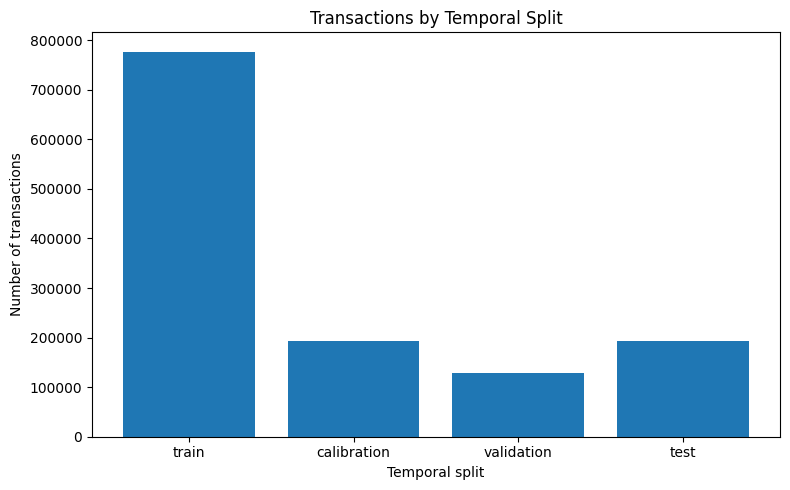

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(split_summary["split"], split_summary["rows"])
plt.xlabel("Temporal split")
plt.ylabel("Number of transactions")
plt.title("Transactions by Temporal Split")
plt.tight_layout()
plt.savefig(
    "/kaggle/working/figures/temporal_split_sizes.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

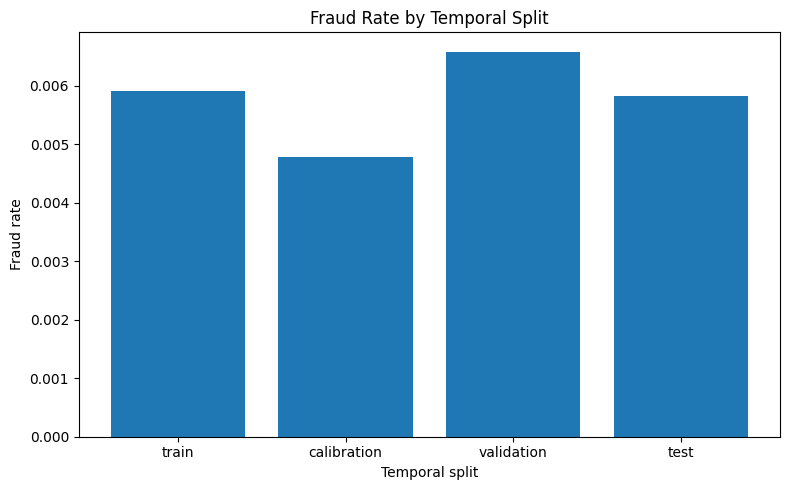

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(split_summary["split"], split_summary["fraud_rate"])
plt.xlabel("Temporal split")
plt.ylabel("Fraud rate")
plt.title("Fraud Rate by Temporal Split")
plt.tight_layout()
plt.savefig(
    "/kaggle/working/figures/temporal_split_fraud_rates.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## 11. Save Split Metadata

The exact split boundaries are saved so that later notebooks use the same train, calibration, validation, and test definitions.

This prevents accidental changes to the test period during later modeling experiments.


In [22]:
split_summary.to_csv(
    "/kaggle/working/results/sparkov_split_summary.csv",
    index=False
)

split_metadata = {
    "train_ratio": TRAIN_RATIO,
    "calibration_ratio": CALIBRATION_RATIO,
    "validation_ratio": VALIDATION_RATIO,
    "test_ratio": TEST_RATIO,
    "purge_hours": PURGE_HOURS,
    "train_boundary_unix": train_boundary,
    "calibration_boundary_unix": calibration_boundary,
    "validation_boundary_unix": validation_boundary,
    "train_start": str(train["trans_date_trans_time"].min()),
    "train_end": str(train["trans_date_trans_time"].max()),
    "calibration_start": str(calibration["trans_date_trans_time"].min()),
    "calibration_end": str(calibration["trans_date_trans_time"].max()),
    "validation_start": str(validation["trans_date_trans_time"].min()),
    "validation_end": str(validation["trans_date_trans_time"].max()),
    "test_start": str(test["trans_date_trans_time"].min()),
    "test_end": str(test["trans_date_trans_time"].max()),
}

with open(
    "/kaggle/working/results/sparkov_split_metadata.json",
    "w"
) as f:
    json.dump(split_metadata, f, indent=4)

print("Split summary and metadata saved.")

Split summary and metadata saved.


In [23]:
with open(
    "/kaggle/working/results/sparkov_split_metadata.json",
    "r"
) as f:
    saved_metadata = json.load(f)

saved_metadata

{'train_ratio': 0.6,
 'calibration_ratio': 0.15,
 'validation_ratio': 0.1,
 'test_ratio': 0.15,
 'purge_hours': 24,
 'train_boundary_unix': 1354217833,
 'calibration_boundary_unix': 1359385476,
 'validation_boundary_unix': 1365011684,
 'train_start': '2019-01-01 00:00:18',
 'train_end': '2019-11-29 07:35:17',
 'calibration_start': '2019-11-30 07:37:20',
 'calibration_end': '2020-01-28 03:04:27',
 'validation_start': '2020-01-29 03:06:41',
 'validation_end': '2020-04-03 05:52:32',
 'test_start': '2020-04-04 05:55:26',
 'test_end': '2020-06-21 12:13:37'}

## 12. Test Set Lock

From this point onward, the test period is considered locked.

The test set must not be used for:

- feature selection
- preprocessing decisions
- model selection
- hyperparameter tuning
- probability calibration
- threshold selection
- cost-parameter selection
- daily alert-capacity selection

Model development will use the training, calibration, and validation periods only.

The test period will be evaluated after the complete modeling and decision pipeline has been finalized.


## Conclusion

The Sparkov transaction stream has been divided into chronological train, calibration, validation, and test periods.

A purge window was introduced between adjacent periods to reduce contamination from temporally adjacent transactions and short fraud episodes.

The roles of the four periods are now fixed:

- **Train:** preprocessing and model fitting
- **Calibration:** probability calibration
- **Validation:** model and decision-policy selection
- **Test:** final evaluation only

No model fitting, scaling, resampling, probability calibration, threshold optimization, or cost tuning was performed before the chronological split.

The next notebook will build baseline fraud-detection models using current-transaction information and the fixed temporal split.
